## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [17]:
#1

import pandas as pd

golub = pd.read_csv("golub.csv")
print(golub.head())
print(golub.columns)

   Samples BM.PB Gender Source tissue.mf cancer  AFFX-BioB-5_at  \
0       39    BM      F   DFCI      BM:f   allB    -1363.276427   
1       40    BM      F   DFCI      BM:f   allB     -796.285053   
2       42    BM      F   DFCI      BM:f   allB     -679.139168   
3       47    BM      M   DFCI      BM:m   allB    -1164.400197   
4       48    BM      F   DFCI      BM:f   allB    -1299.653758   

   AFFX-BioB-M_at  AFFX-BioB-3_at  AFFX-BioC-5_at  ...   U48730_at  \
0    -1058.585495     -541.469194       74.349803  ...  -35.081447   
1    -1167.103365        7.538493       83.544731  ... -404.737767   
2    -1069.832308     -690.301829     -112.075981  ...  193.780934   
3    -1109.939891     -990.127218     -238.574994  ... -256.002292   
4    -1401.998536    -1077.543813     -437.344560  ... -509.203660   

     U58516_at    U73738_at   X06956_at    X16699_at    X83863_at   Z17240_at  \
0  1565.618803  -485.680714 -170.261227  -919.114293  1675.050053  389.769289   
1   622.498054

In [18]:
golub["target"] = golub["cancer"].map({
    "allB": 0,
    "allT": 0,
    "aml": 1
})

print(golub[["cancer", "target"]].head())
print(golub["target"].value_counts())

  cancer  target
0   allB       0
1   allB       0
2   allB       0
3   allB       0
4   allB       0
target
0    47
1    25
Name: count, dtype: int64


In [19]:
#2

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X = golub.select_dtypes(include=[np.number]).drop(columns=["target"])

y = golub["target"]

print(X.shape)

(72, 7130)


In [20]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

In [21]:
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 1.4072128126989404e-30


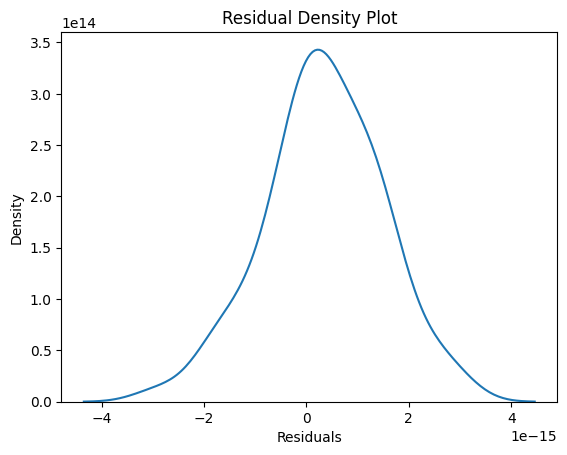

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y - y_pred

sns.kdeplot(residuals)
plt.title("Residual Density Plot")
plt.xlabel("Residuals")
plt.show()

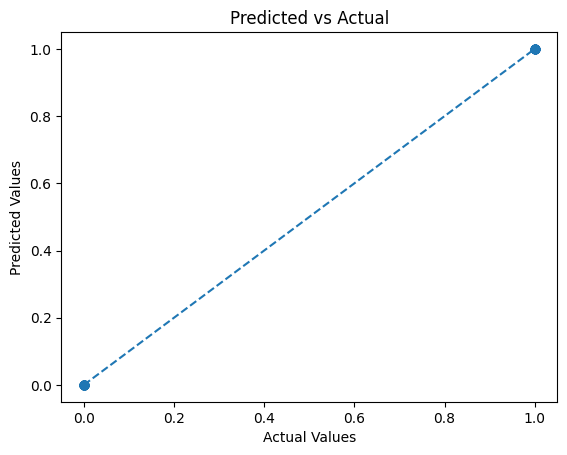

In [23]:
plt.scatter(y, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.show()

In [24]:
#3

from sklearn.model_selection import cross_val_score, KFold

model = LinearRegression()

kf = KFold(n_splits=10, shuffle=True, random_state=1)

cv_mse = -cross_val_score(model, X, y,
                          scoring='neg_mean_squared_error',
                          cv=kf)

print("MSE for each fold:", cv_mse)
print("Average CV MSE:", cv_mse.mean())

MSE for each fold: [0.04838762 0.03536298 0.07254137 0.01960351 0.06120782 0.04814321
 0.09781032 0.04182106 0.05022565 0.02226711]
Average CV MSE: 0.04973706669940568


The average cross-validated mean squared error (MSE) is approximately 0.0497, which is higher than the training MSE from Question 2, indicating that the linear regression model is overfitting the data. This reflects the bias-variance trade-off, where the model has very low bias due to its ability to fit a large number of gene features, but high variance because it is extremely sensitive to small changes in the dataset. With far more predictors than observations, the model effectively memorizes the training data rather than learning generalizable patterns, leading to worse performance on unseen data. The higher cross-validated MSE captures this lack of generalization, showing that while the model fits the training data well, it does not perform as effectively out-of-sample.


In [25]:
#4

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np

In [26]:
lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=1, max_iter=10000)
)

lasso_model.fit(X, y)

y_pred_lasso = lasso_model.predict(X)

In [27]:
lasso_cv = lasso_model.named_steps["lassocv"]

coef = lasso_cv.coef_

selected_genes = X.columns[coef != 0]
selected_coefs = coef[coef != 0]

selected_df = pd.DataFrame({
    "gene": selected_genes,
    "coefficient": selected_coefs
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Optimal alpha:", lasso_cv.alpha_)
print("Number of selected genes:", len(selected_genes))
print("Number of discarded genes:", X.shape[1] - len(selected_genes))
print(selected_df)

Optimal alpha: 0.0006701743064744867
Number of selected genes: 80
Number of discarded genes: 7050
           gene  coefficient
16    M19507_at     0.122462
20    M27891_at     0.072437
22    M31994_at     0.061105
18    M22960_at     0.046373
19    M23197_at     0.043148
..          ...          ...
79    X06318_at    -0.000139
24    M84526_at     0.000108
74  U26312_s_at    -0.000079
12    L13848_at    -0.000057
5     D42043_at    -0.000014

[80 rows x 2 columns]


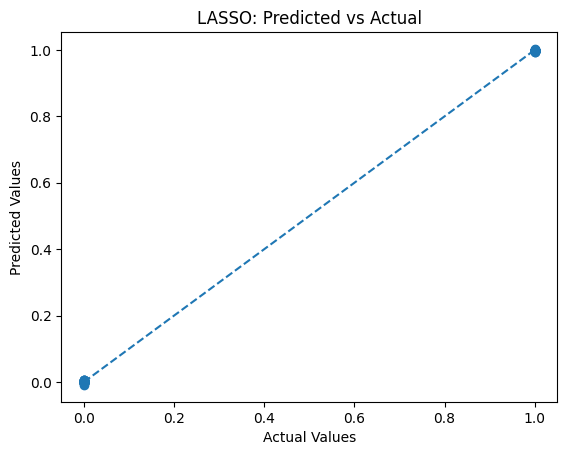

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("LASSO: Predicted vs Actual")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

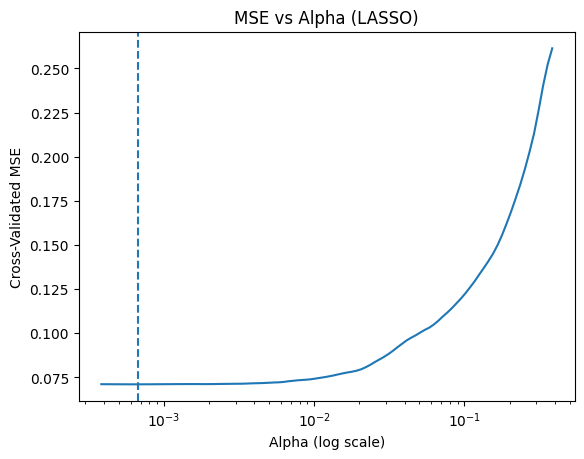

In [29]:
#5

import matplotlib.pyplot as plt
import numpy as np

alphas = lasso_cv.alphas_
mse_path = lasso_cv.mse_path_.mean(axis=1)

plt.plot(alphas, mse_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-Validated MSE")
plt.title("MSE vs Alpha (LASSO)")

plt.axvline(lasso_cv.alpha_, linestyle='--')

plt.show()

The cross-validated mean squared error (MSE) increases as the penalty parameter α increases, with the optimal value at approximately α = 0.00067, which minimizes the expected MSE. When α is very small, the model applies little regularization and includes many predictors, leading to overfitting, as it captures noise in the data and results in higher variance. As α increases, the model becomes simpler by shrinking more coefficients toward zero, reducing variance but increasing bias. At very large values of α, the model becomes too simple and begins to underfit, failing to capture important relationships in the data and producing higher error. Thus, the optimal α balances this trade-off between bias and variance, achieving the lowest cross-validated MSE and the best generalization performance.

6. Linear regression performs almost perfectly on the training set because it uses all of the gene variables in a setting where the number of predictors is extremely large relative to the number of observations, giving the model enough flexibility to fit not only the true signal but also random noise in the sample. This leads to overfitting: the model has very low training error but poor generalization to new data. The LASSO adds a penalty that shrinks many coefficients toward zero and removes less useful genes from the model, forcing it to focus on the strongest predictors. Although this means the LASSO may not fit the training data quite as perfectly, it reduces variance and improves out-of-sample prediction.

7. Regularization methods like the LASSO are particularly well-suited for precision health because these settings often involve extremely high-dimensional data, such as genomics, where the number of predictors (genes) far exceeds the number of patients. By shrinking coefficients and selecting only the most relevant variables, regularization helps identify a smaller set of meaningful biomarkers that are truly associated with disease outcomes, improving interpretability and reducing overfitting. This leads to more reliable and generalizable predictions, which is critical when making clinical decisions.

8. Regularization methods like LASSO in precision health carry important risks because model outputs can directly inform clinical decisions. One concern is that LASSO may omit relevant genes due to noise or multicollinearity, leading to biased or incomplete conclusions. Additionally, if the training data is not representative, predictions may not generalize well across patient populations, raising concerns about external validity and equity. There is also a risk of overinterpreting a simplified model, which may fail to capture complex biological interactions. As a result, improper application could lead to suboptimal or even harmful treatment decisions, making careful validation essential.
